# Notebook 2 — Simulation & Numerical Reliability

## Goal

Learn how numerical settings affect first-principles calculations and how to determine whether a calculation is sufficiently converged.

The core idea is:

**change numerical settings → compare calculated energies → evaluate convergence → choose reliable parameters**

## 1. Read Convergence Results

- collect results from multiple VASP calculations
- extract ENCUT, k-point settings, and total energies
- organise the results into a structured dataset

## 2. ENCUT Convergence

- compare total energies at different ENCUT values
- calculate energy differences relative to a reference calculation
- determine when the energy becomes sufficiently stable

## 3. K-point Convergence

- compare calculations using different k-point meshes
- evaluate changes in energy per atom
- select a sufficiently converged k-point sampling

## 4. Summary

In [1]:
from pymatgen.io.vasp.inputs import Potcar, Kpoints, Incar, Poscar, VaspInput
from monty.serialization import loadfn
from pathlib import Path
from pymatgen.core import Structure
import doped

In [ ]:
#collect results from multiple VASP calculations
project_root = Path.cwd().parent
data_root = (
    project_root
    /"data"
    /"raw"
    /"mgo_defect_thermodynamics_dataset"
)
convergence_root = (data_root /"01_bulk_convergence")

# test whether exist
print("convergence_dictionary:",convergence_root)
print("Dictionary exist:", convergence_root.exists())

#Check convergence file from the known dictionary Path.iterdir()
for item in sorted(convergence_root.iterdir()):
    print(item.name)

#rglob()
all_outcar_paths = list(
    convergence_root.rglob("OUTCAR")
)

print("Number of OUTCAR files:", len(all_outcar_paths))

for path in sorted(all_outcar_paths):
    print(path.relative_to(convergence_root))

convergence_dictionary: /Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence
Dictionary exist: True
encut
kpoints
Number of OUTCAR files: 13
encut/ENCUT_350/OUTCAR
encut/ENCUT_400/OUTCAR
encut/ENCUT_450/OUTCAR
encut/ENCUT_500/OUTCAR
encut/ENCUT_550/OUTCAR
encut/ENCUT_600/OUTCAR
encut/ENCUT_650/OUTCAR
kpoints/KPOINTS_2x2x2/OUTCAR
kpoints/KPOINTS_3x3x3/OUTCAR
kpoints/KPOINTS_4x4x4/OUTCAR
kpoints/KPOINTS_5x5x5/OUTCAR
kpoints/KPOINTS_6x6x6/OUTCAR
kpoints/KPOINTS_8x8x8/OUTCAR


In [3]:
# Filtering of OUTCAR of ENCUT
encut_outcar_paths = []
for path in all_outcar_paths:
    path_text = str(path).lower()
    if "encut" in path_text:
        encut_outcar_paths.append(path)

print("ENCUT OUTCAR files:",encut_outcar_paths)

print("All OUTCAR files:", len(all_outcar_paths))
print("ENCUT OUTCAR files:", len(encut_outcar_paths))


ENCUT OUTCAR files: [PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_650/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_400/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_550/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_600/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_450/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_350/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_500/OUTCAR')]
All OUTCAR files: 13
ENCUT OUTCAR files: 7


In [ ]:
#Inspect a VASP OUTCAR
sample_outcar = sorted(encut_outcar_paths)[0]

text = sample_outcar.read_text(encoding="utf-8")
lines = text.splitlines()

print("Sample file:", sample_outcar)
print("Number of lines:", len(lines))

for line in lines:
    if "ENCUT" in line:
        print(line)

for line in lines:
    if "TOTEN" in line:
        print(line)

Sample file: /Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_350/OUTCAR
Number of lines: 45
  ENCUT = 350
  free  energy   TOTEN  = -102.31851400 eV


In [ ]:
# extract ENCUT, k-point settings, and total energies
encut_value = None
toten_values = []

for line in lines:
    if "ENCUT" in line:
        right_side = line.split("=", 1)[1]
        encut_value = float(right_side.split()[0])

    if "TOTEN" in line:
        right_side = line.split("=", 1)[1]
        total_energy = float(right_side.split()[0])
        toten_values.append(total_energy)

final_toten = toten_values[-1]

# Get the number of atoms from the POSCAR used in this calculation
poscar_path = sample_outcar.parent / "POSCAR"
structure = Structure.from_file(poscar_path)

number_of_atoms = structure.num_sites
energy_per_atom = final_toten / number_of_atoms

converged = "reached required accuracy" in text.lower()

result = {
    "encut_eV": encut_value,
    "total_energy_eV": final_toten,
    "energy_per_atom_eV": energy_per_atom,
    "converged": converged,
    "outcar_path": sample_outcar,
}

print(result)

{'encut_eV': 350.0, 'total_energy_eV': -102.318514, 'energy_per_atom_eV': -12.78981425, 'converged': True, 'outcar_path': PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_350/OUTCAR')}


In [ ]:
#We can refactor this code into a reusable function.
def parse_encut_outcar(
    outcar_path: Path,
    number_of_atoms: int,
) -> dict:
    """Parse ENCUT and final TOTEN from one OUTCAR-like file."""

    text = outcar_path.read_text(encoding="utf-8")
    lines = text.splitlines()

    encut_value = None
    toten_values = []

    for line in lines:
        if "ENCUT" in line:
            right_side = line.split("=", 1)[1]
            encut_value = float(right_side.split()[0])

        if "TOTEN" in line:
            right_side = line.split("=", 1)[1]
            total_energy = float(right_side.split()[0])
            toten_values.append(total_energy)

    final_toten = toten_values[-1]
    energy_per_atom = final_toten / number_of_atoms

    converged = "reached required accuracy" in text.lower()

    return {
        "encut_eV": encut_value,
        "total_energy_eV": final_toten,
        "energy_per_atom_eV": energy_per_atom,
        "converged": converged,
        "outcar_path": outcar_path,
    }

In [ ]:
# organise the results into a structured dataset
encut_records = []
poscar_path = sample_outcar.parent / "POSCAR"
structure = Structure.from_file(poscar_path)

for outcar_path in encut_outcar_paths:
    result = parse_encut_outcar(
        outcar_path=outcar_path,
        number_of_atoms=structure.num_sites,
    )

    encut_records.append(result)

import pandas as pd

encut_df = pd.DataFrame(encut_records)

encut_df = (
    encut_df
    .sort_values("encut_eV")
    .reset_index(drop=True)
)

display(
    encut_df[
        [
            "encut_eV",
            "energy_per_atom_eV",
            "converged",
        ]
    ]
)

,encut_eV,energy_per_atom_eV,converged
0,350.0,-12.789814,True
1,400.0,-12.795852,True
2,450.0,-12.799002,True
3,500.0,-12.799877,True
4,550.0,-12.800127,True
5,600.0,-12.800177,True
6,650.0,-12.800189,True


## 2. ENCUT Convergence

In [ ]:
# Compare total energies at different ENCUT values and select reference value
encut_df = (
    encut_df
    .sort_values("encut_eV")
    .reset_index(drop=True)
)

reference_energy = encut_df["energy_per_atom_eV"].iloc[-1]

In [ ]:
# calculate energy differences relative to a reference calculation
encut_df["delta_meV_per_atom"] = (abs( encut_df["energy_per_atom_eV"] - reference_energy)* 1000)

display(
    encut_df[
        [
            "encut_eV",
            "energy_per_atom_eV",
            "delta_meV_per_atom",
        ]
    ]
)

,encut_eV,energy_per_atom_eV,delta_meV_per_atom
0,350.0,-12.789814,10.3750
1,400.0,-12.795852,4.3375
2,450.0,-12.799002,1.1875
3,500.0,-12.799877,0.3125
4,550.0,-12.800127,0.0625
5,600.0,-12.800177,0.0125
6,650.0,-12.800189,0.0000


In [ ]:
#Choose the convergence value and select 
threshold = 5.0

converged_rows = encut_df[encut_df["delta_meV_per_atom"] <= 5]

selected_encut = converged_rows.iloc[0]["encut_eV"]

print("Selected ENCUT:", selected_encut, "eV")



Selected ENCUT: 400.0 eV


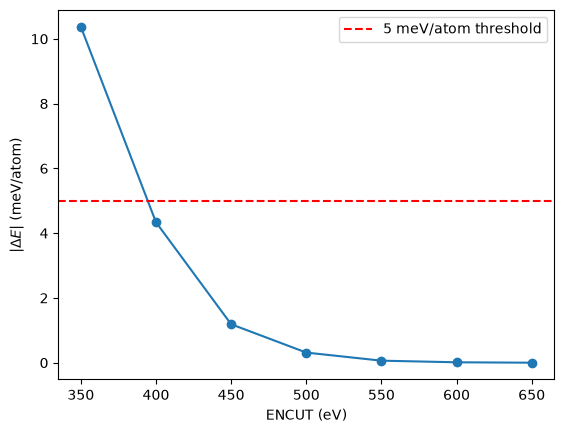

In [17]:
# Plot
import matplotlib.pyplot as plt

plt.plot(
    encut_df["encut_eV"],
    encut_df["delta_meV_per_atom"],
    marker="o",
)

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label="5 meV/atom threshold",
)

plt.xlabel("ENCUT (eV)")
plt.ylabel(r"$|\Delta E|$ (meV/atom)")
plt.legend()
plt.show()

## 3.K-point Convergence. #TODO since the method is similar with ENCUT's

## 4. Summary

In this notebook, I learned how to organise and extract useful information from multiple VASP calculation folders, and how these data can be used for convergence analysis.

The first step is to identify the relevant output files and extract the quantities needed for comparison, such as ENCUT and the final total energy.

The second step is to evaluate numerical convergence. In general, increasing ENCUT improves the completeness of the plane-wave basis, but it also increases computational cost.

Therefore, the goal is not simply to use the largest possible ENCUT, but to choose a value beyond which further increases produce only negligible changes in the calculated energy.

The main idea is:

**collect calculation results → extract comparable data → evaluate energy changes → choose a sufficiently converged setting**